# Cloud-Root Structure: Free 3D−1D vs Nudged 3D−1D

Compares three cases from the `no_aerosols_zero_wind` and `mean_state_nudge` experiments:

| Key | Description | Experiment |
|-----|-------------|------------|
| **1D** | 1D free run (2stream) | `no_aerosols_zero_wind/2stream` |
| **3D** | 3D free run (raytracer) | `no_aerosols_zero_wind/raytracer` |
| **3D nudge** | 3D nudged toward 1D mean state (τ=3600 s) | `mean_state_nudge/nudge_3600s/raytracer` |

**Section A** — Normalised cloud-root flux profiles: per-rep identification → time-mean per rep → mean ± 1σ across reps  
**Section B** — L&P composite cross-sections (3-row: 1D | 3D free | 3D nudged; shared colour limits)  
**Section C** — Difference composites: 3D−1D, nudged−1D, nudged−3D


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # -> analysis/
sys.path.insert(0, str(Path.cwd()))          # -> analysis/cloud_roots/

from cass_analysis import (
    load_stats,
    load_3d_nc,
    load_xy_files,
    compute_normalized_cloud_root_profiles,
    plot_cloud_root_composite,
    COMPOSITE_VARS,
)
from cloud_root_composite_average import average_reps

# ── CONFIGURATION ─────────────────────────────────────────────────────────────────────────────
SCRATCH        = '/pscratch/sd/m/mpowell/CASS_LES'
COMPOSITE_ROOT = f'{SCRATCH}/analysis/cloud_root_composite'
N_REPS         = 4
ORIENT         = 'xz'   # change to 'yz' for perpendicular composite
LST_MIN        = 10.5   # LST hours — change freely, cache stores all timesteps
LST_MAX        = 17.5
# ───────────────────────────────────────────────────────────────────────────────

CASES = [
    dict(
        key       = '1D',
        label     = '1D (2stream)',
        run_root  = f'{SCRATCH}/experiments/no_aerosols_zero_wind/2stream',
        comp_expt = 'no_aerosols_zero_wind',
        comp_rt   = '2stream',
        color     = 'C0',
        ls        = '-',
    ),
    dict(
        key       = '3D',
        label     = '3D (raytracer)',
        run_root  = f'{SCRATCH}/experiments/no_aerosols_zero_wind/raytracer',
        comp_expt = 'no_aerosols_zero_wind',
        comp_rt   = 'raytracer',
        color     = 'C1',
        ls        = '-',
    ),
    # dict(
    #     key       = '3D_nudge',
    #     label     = '3D nudged (τ=3600 s)',
    #     run_root  = f'{SCRATCH}/experiments/mean_state_nudge/nudge_3600s/raytracer',
    #     comp_expt = 'mean_state_nudge/nudge_3600s',
    #     comp_rt   = 'raytracer',
    #     color     = 'C3',
    #     ls        = '--',
    # ),
]
print('Config loaded.')

Config loaded.


In [2]:
print('Data availability check')
print('=' * 72)
for c in CASES:
    run_root = Path(c['run_root'])
    n_3d = n_events = 0
    for i in range(1, N_REPS + 1):
        rd = run_root / f'rep_{i:02d}'
        if (rd / 'thl.nc').exists():
            n_3d += 1
        ev = (Path(COMPOSITE_ROOT) / c['comp_expt'] / c['comp_rt']
              / f'rep_{i:02d}' / f'events_{ORIENT}.nc')
        if ev.exists() and ev.stat().st_size > 1000:
            n_events += 1
    print(f'  {c["label"]:40s}  3D nc: {n_3d}/{N_REPS}   events_{ORIENT}: {n_events}/{N_REPS}')

Data availability check
  1D (2stream)                              3D nc: 4/4   events_xz: 4/4
  3D (raytracer)                            3D nc: 4/4   events_xz: 4/4


## Section A — Normalised cloud-root flux profiles

For each rep **independently**:
1. Load 3D fields (`thl.nc`, `qt.nc`, `ql.nc`, `w.nc` from `3d_to_nc.py`)
2. Identify cloud-root columns (LWP > 0 from nearest XY dump)
3. Compute `w'θ_l'` and `w'q_v'` conditioned on cloud-root columns, normalised by the domain-mean sub-cloud integral
4. Time-average the normalised profile across all 3D dump times

Then: mean ± 1σ across reps (shaded band).

> **Note**: this cell loads 3D fields for all reps — expect a few minutes per case.

In [3]:
def normalize_profiles(f_cloud, f_domain, zeta_grid, z_sl_arr):
    """Apply sub-cloud peak normalisation to cached raw flux profiles.

    f_cloud, f_domain : (n_times, n_zeta) on the standard zeta grid
    z_sl_arr          : (n_times,) in metres
    Returns (n_times, n_zeta) normalised array.
    """
    out = np.full_like(f_cloud, np.nan)
    scl_mask = zeta_grid <= 1.0
    for t in range(f_cloud.shape[0]):
        peak = float(np.nanmax(np.abs(f_domain[t, scl_mask])))
        if peak > 1e-6:
            out[t] = f_cloud[t] / peak
    return out


def load_case_profiles(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Per-rep normalised cloud-root flux profiles, time-averaged, stacked across reps.

    Cache stores ALL dump times with their LST hours; the LST window is applied
    here at load time, so changing LST_MIN/LST_MAX never requires a cache rebuild.

    Cache is invalidated if f_free_thl or t_hours is missing.
    """
    run_root = Path(case['run_root'])
    thl_reps, qv_reps = [], []
    zeta = None

    for i in range(1, n_reps + 1):
        rep_dir = run_root / f'rep_{i:02d}'
        if not (rep_dir / 'thl.nc').exists():
            print(f'  SKIP {case["key"]} rep_{i:02d}: thl.nc not found')
            continue

        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')

        # Invalidate caches missing f_free_thl or t_hours
        if cache_path.exists():
            with xr.open_dataset(str(cache_path)) as _chk:
                if 'f_free_thl' not in _chk or 't_hours' not in _chk:
                    print(f'  {case["key"]} rep_{i:02d}: cache outdated, recomputing')
                    cache_path.unlink()

        if cache_path.exists():
            print(f'  {case["key"]} rep_{i:02d}: cache hit')
            ds_c = xr.open_dataset(str(cache_path))
            zeta       = ds_c['zeta'].values
            t_hrs      = ds_c['t_hours'].values
            mask_t     = (t_hrs >= lst_min) & (t_hrs <= lst_max)
            f_cl_thl   = ds_c['f_cloud_thl'].values[mask_t]
            f_cl_qv    = ds_c['f_cloud_qv'].values[mask_t]
            f_fr_thl   = ds_c['f_free_thl'].values[mask_t]
            f_fr_qv    = ds_c['f_free_qv'].values[mask_t]
            f_dm_thl   = ds_c['f_domain_thl'].values[mask_t]
            f_dm_qv    = ds_c['f_domain_qv'].values[mask_t]
            z_sl_arr   = ds_c['z_sl'].values[mask_t]
            ds_c.close()
            n_t = int(mask_t.sum())
            print(f'    {n_t} timesteps in [{lst_min}, {lst_max}] LST')
        else:
            print(f'  {case["key"]} rep_{i:02d} (computing) ...', end=' ', flush=True)
            stats = load_stats(rep_dir)
            ds_3d = load_3d_nc(rep_dir, variables=['thl', 'qt', 'ql', 'w'])
            ds_xy = load_xy_files(rep_dir, variables=['qlqi_path'])
            res   = compute_normalized_cloud_root_profiles(ds_3d, ds_xy, stats)
            ds_3d.close()
            zeta = res['zeta']

            n_t = res['f_cloud_thl'].shape[0]
            print(f'{n_t} total timesteps')

            if n_t == 0:
                print(f'    WARNING: rep_{i:02d} — no valid timesteps, skipping')
                continue

            # Save ALL timesteps to cache
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            xr.Dataset({
                'f_cloud_thl':  xr.DataArray(res['f_cloud_thl'],  dims=['time', 'zeta']),
                'f_cloud_qv':   xr.DataArray(res['f_cloud_qv'],   dims=['time', 'zeta']),
                'f_free_thl':   xr.DataArray(res['f_free_thl'],   dims=['time', 'zeta']),
                'f_free_qv':    xr.DataArray(res['f_free_qv'],    dims=['time', 'zeta']),
                'f_domain_thl': xr.DataArray(res['f_domain_thl'], dims=['time', 'zeta']),
                'f_domain_qv':  xr.DataArray(res['f_domain_qv'],  dims=['time', 'zeta']),
                'z_sl':         xr.DataArray(res['z_sl'],          dims=['time']),
                'cloud_frac':   xr.DataArray(res['cloud_frac'],    dims=['time']),
                't_hours':      xr.DataArray(res['t_hours'],       dims=['time']),
            }, coords={'zeta': zeta}).to_netcdf(str(cache_path))

            # Apply LST filter for this run
            mask_t   = (res['t_hours'] >= lst_min) & (res['t_hours'] <= lst_max)
            f_cl_thl = res['f_cloud_thl'][mask_t]
            f_cl_qv  = res['f_cloud_qv'][mask_t]
            f_fr_thl = res['f_free_thl'][mask_t]
            f_fr_qv  = res['f_free_qv'][mask_t]
            f_dm_thl = res['f_domain_thl'][mask_t]
            f_dm_qv  = res['f_domain_qv'][mask_t]
            z_sl_arr = res['z_sl'][mask_t]
            print(f'    {int(mask_t.sum())} timesteps in [{lst_min}, {lst_max}] LST')

        if len(z_sl_arr) == 0:
            print(f'    WARNING: rep_{i:02d} — no timesteps in LST window, skipping')
            continue

        thl_nd   = normalize_profiles(f_cl_thl, f_dm_thl, zeta, z_sl_arr)
        qv_nd    = normalize_profiles(f_cl_qv,  f_dm_qv,  zeta, z_sl_arr)
        thl_mean = np.nanmean(thl_nd, axis=0)
        qv_mean  = np.nanmean(qv_nd,  axis=0)

        if np.all(np.isnan(thl_mean)):
            print(f'    WARNING: rep_{i:02d} all-NaN after normalisation — skipping')
            continue

        thl_reps.append(thl_mean)
        qv_reps.append(qv_mean)

    return dict(
        zeta   = zeta,
        thl    = np.stack(thl_reps) if thl_reps else np.empty((0,)),
        qv     = np.stack(qv_reps)  if qv_reps  else np.empty((0,)),
        n_reps = len(thl_reps),
    )

In [4]:
profiles = {}
for case in CASES:
    print(f'\n{case["label"]}')
    profiles[case['key']] = load_case_profiles(case)
    print(f'  -> {profiles[case["key"]]["n_reps"]} reps loaded')


1D (2stream)
  1D rep_01: cache hit
    8 timesteps in [10.5, 17.5] LST
  1D rep_02: cache hit
    8 timesteps in [10.5, 17.5] LST
  1D rep_03: cache hit
    8 timesteps in [10.5, 17.5] LST
  1D rep_04: cache hit
    8 timesteps in [10.5, 17.5] LST
  -> 4 reps loaded

3D (raytracer)
  3D rep_01: cache hit
    8 timesteps in [10.5, 17.5] LST
  3D rep_02: cache hit
    8 timesteps in [10.5, 17.5] LST
  3D rep_03: cache hit
    8 timesteps in [10.5, 17.5] LST
  3D rep_04: cache hit
    8 timesteps in [10.5, 17.5] LST
  -> 4 reps loaded


/tmp/ipykernel_2028972/1481473392.py:108: RuntimeWarning: Mean of empty slice
  thl_mean = np.nanmean(thl_nd, axis=0)
/tmp/ipykernel_2028972/1481473392.py:109: RuntimeWarning: Mean of empty slice
  qv_mean  = np.nanmean(qv_nd,  axis=0)
/tmp/ipykernel_2028972/1481473392.py:108: RuntimeWarning: Mean of empty slice
  thl_mean = np.nanmean(thl_nd, axis=0)
/tmp/ipykernel_2028972/1481473392.py:109: RuntimeWarning: Mean of empty slice
  qv_mean  = np.nanmean(qv_nd,  axis=0)
/tmp/ipykernel_2028972/1481473392.py:108: RuntimeWarning: Mean of empty slice
  thl_mean = np.nanmean(thl_nd, axis=0)
/tmp/ipykernel_2028972/1481473392.py:109: RuntimeWarning: Mean of empty slice
  qv_mean  = np.nanmean(qv_nd,  axis=0)
/tmp/ipykernel_2028972/1481473392.py:108: RuntimeWarning: Mean of empty slice
  thl_mean = np.nanmean(thl_nd, axis=0)
/tmp/ipykernel_2028972/1481473392.py:109: RuntimeWarning: Mean of empty slice
  qv_mean  = np.nanmean(qv_nd,  axis=0)
/tmp/ipykernel_2028972/1481473392.py:108: RuntimeWarning

## Section A — Absolute turbulent flux profiles (H and LE)

Same cache as Section A — no additional I/O.  Scales the raw `w'θ_l'` and `w'q_v'` profiles
by `ρ·cₚ` and `ρ·Lᵥ` to get **H(z)** and **LE(z)** in W m⁻².

Each panel shows:
- **solid line** — domain-mean flux profile
- **dashed line** — cloud-root-conditioned flux profile (columns with LWP > 0 overhead)

The gap between solid and dashed is the absolute magnitude of the cloud-root enhancement,
directly comparable to the surface SEB values.

In [5]:
# ── Physical constants (match cass_analysis.py) ──────────────────────────────
_RHO    = 1.2       # kg m⁻³  reference surface density
_CP     = 1005.0    # J kg⁻¹ K⁻¹
_LV     = 2.5e6     # J kg⁻¹
# f_*_thl is in K m/s      →  H  = rho*cp * flux            (W/m²)
# f_*_qv  is in g/kg m/s   →  LE = rho*Lv * flux * 1e-3    (W/m²)
RHO_CP  = _RHO * _CP          # ~1206
RHO_LV  = _RHO * _LV * 1e-3   # ~3000


def load_absolute_profiles(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Load cached raw flux profiles and convert to H / LE in W m⁻².

    Applies the same LST_MIN/LST_MAX window as load_case_profiles.
    """
    H_dom_reps,  H_root_reps,  H_free_reps  = [], [], []
    LE_dom_reps, LE_root_reps, LE_free_reps = [], [], []
    zeta = None

    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache not found (run Section A first)')
            continue

        ds_c = xr.open_dataset(str(cache_path))
        if 'f_free_thl' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache outdated — re-run Section A cell')
            continue

        zeta    = ds_c['zeta'].values
        t_hrs   = ds_c['t_hours'].values
        mask_t  = (t_hrs >= lst_min) & (t_hrs <= lst_max)

        f_dom_thl  = ds_c['f_domain_thl'].values[mask_t]
        f_root_thl = ds_c['f_cloud_thl'].values[mask_t]
        f_free_thl = ds_c['f_free_thl'].values[mask_t]
        f_dom_qv   = ds_c['f_domain_qv'].values[mask_t]
        f_root_qv  = ds_c['f_cloud_qv'].values[mask_t]
        f_free_qv  = ds_c['f_free_qv'].values[mask_t]
        ds_c.close()

        if mask_t.sum() == 0:
            print(f'  SKIP {case["key"]} rep_{i:02d}: no timesteps in [{lst_min}, {lst_max}] LST')
            continue

        H_dom_reps.append(  np.nanmean(f_dom_thl  * RHO_CP, axis=0))
        H_root_reps.append( np.nanmean(f_root_thl * RHO_CP, axis=0))
        H_free_reps.append( np.nanmean(f_free_thl * RHO_CP, axis=0))
        LE_dom_reps.append(  np.nanmean(f_dom_qv  * RHO_LV, axis=0))
        LE_root_reps.append( np.nanmean(f_root_qv * RHO_LV, axis=0))
        LE_free_reps.append( np.nanmean(f_free_qv * RHO_LV, axis=0))

    def _stack(lst):
        return np.stack(lst) if lst else np.empty((0,))

    return dict(
        zeta     = zeta,
        H_dom    = _stack(H_dom_reps),
        H_root   = _stack(H_root_reps),
        H_free   = _stack(H_free_reps),
        LE_dom   = _stack(LE_dom_reps),
        LE_root  = _stack(LE_root_reps),
        LE_free  = _stack(LE_free_reps),
        n_reps   = len(H_dom_reps),
    )


abs_profiles = {}
for case in CASES:
    print(f'{case["label"]} ... ', end='', flush=True)
    abs_profiles[case['key']] = load_absolute_profiles(case)
    print(f'{abs_profiles[case["key"]]["n_reps"]} reps')

1D (2stream) ... 4 reps
3D (raytracer) ... 4 reps


/tmp/ipykernel_2028972/287278512.py:49: RuntimeWarning: Mean of empty slice
  H_dom_reps.append(  np.nanmean(f_dom_thl  * RHO_CP, axis=0))
/tmp/ipykernel_2028972/287278512.py:50: RuntimeWarning: Mean of empty slice
  H_root_reps.append( np.nanmean(f_root_thl * RHO_CP, axis=0))
/tmp/ipykernel_2028972/287278512.py:51: RuntimeWarning: Mean of empty slice
  H_free_reps.append( np.nanmean(f_free_thl * RHO_CP, axis=0))
/tmp/ipykernel_2028972/287278512.py:52: RuntimeWarning: Mean of empty slice
  LE_dom_reps.append(  np.nanmean(f_dom_qv  * RHO_LV, axis=0))
/tmp/ipykernel_2028972/287278512.py:53: RuntimeWarning: Mean of empty slice
  LE_root_reps.append( np.nanmean(f_root_qv * RHO_LV, axis=0))
/tmp/ipykernel_2028972/287278512.py:54: RuntimeWarning: Mean of empty slice
  LE_free_reps.append( np.nanmean(f_free_qv * RHO_LV, axis=0))
/tmp/ipykernel_2028972/287278512.py:49: RuntimeWarning: Mean of empty slice
  H_dom_reps.append(  np.nanmean(f_dom_thl  * RHO_CP, axis=0))
/tmp/ipykernel_2028972/2872

/tmp/ipykernel_2028972/3961348736.py:36: RuntimeWarning: Mean of empty slice
  mu  = np.nanmean(arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


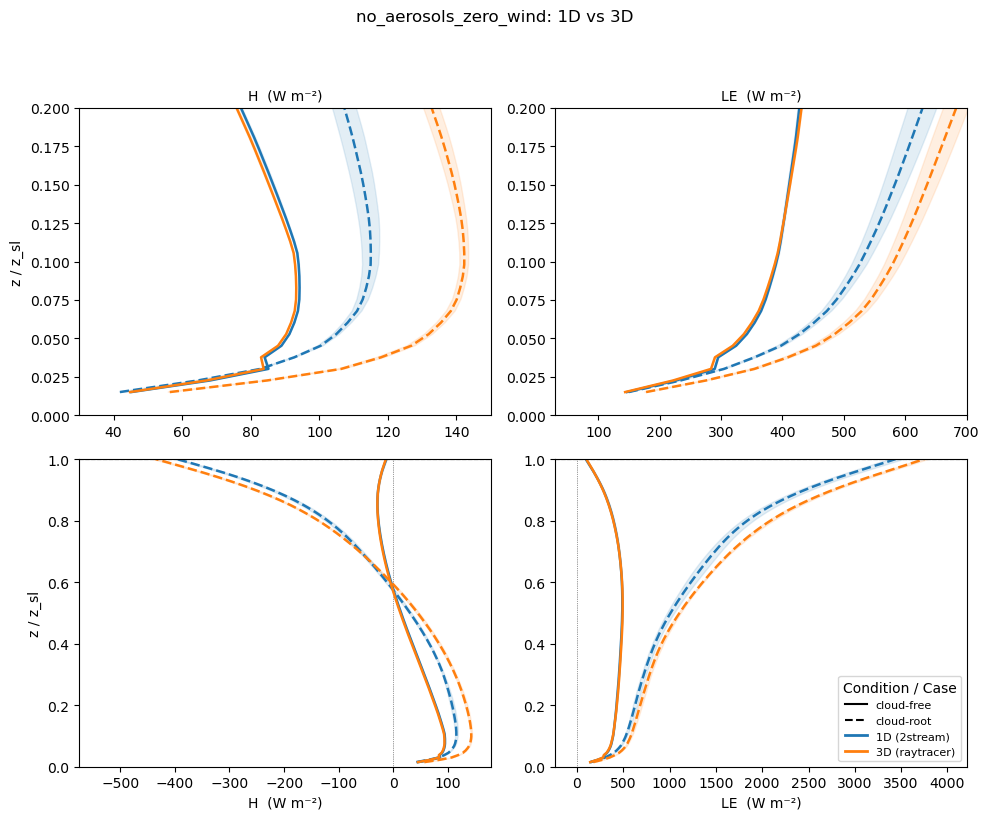

Saved absolute_flux_profiles.pdf


In [16]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

CONDS = [
    ('H_root', 'LE_root', 'cloud-root',  '--'),
    ('H_free', 'LE_free', 'cloud-free',  '-'),
]

for case in CASES:
    ap = abs_profiles[case['key']]

    for col, var in enumerate(['H', 'LE']):
        for row in range(2):
            ax = axes[row, col]

            ax.axhline(1.0, color='gray', ls='--', lw=0.8)
            ax.axvline(0,   color='gray', ls=':',  lw=0.5)

            # Row-specific y-limits
            ax.set_ylim(0, 0.2 if row == 0 else 1)

            # x-limits
            if row == 0:
                ax.set_xlim(30, 150 if var == 'H' else 700)

            if ap['n_reps'] == 0:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                        ha='center', va='center', color='gray')
                continue

            zeta = ap['zeta']

            for h_key, le_key, lbl, ls in CONDS:
                arr = ap[h_key if var == 'H' else le_key]
                mu  = np.nanmean(arr, axis=0)
                sd  = np.nanstd(arr, axis=0, ddof=1) if ap['n_reps'] > 1 else np.zeros_like(mu)

                ax.plot(mu, zeta, color=case['color'], ls=ls, lw=1.8)
                ax.fill_betweenx(zeta, mu - sd, mu + sd,
                                 alpha=0.12, color=case['color'])

            if row == 0:
                ax.set_title('H  (W m⁻²)' if var == 'H' else 'LE  (W m⁻²)', fontsize=10)

            if row == 1:
                ax.set_xlabel('H  (W m⁻²)' if var == 'H' else 'LE  (W m⁻²)')

            if col == 0:
                ax.set_ylabel('z / z_sl')

# Linestyle legend (conditions)
legend_style = [
    Line2D([0],[0], color='k', ls='-',  lw=1.5, label='cloud-free'),
    Line2D([0],[0], color='k', ls='--', lw=1.5, label='cloud-root'),
]

# Color legend (cases)
legend_cases = [
    Line2D([0],[0], color=case['color'], lw=2, label=case['label'])
    for case in CASES
]

combined_handles = legend_style + legend_cases

axes[1,1].legend(
    handles=combined_handles,
    fontsize=8,
    loc='lower right',
    title='Condition / Case'
)

plt.suptitle(
    'no_aerosols_zero_wind: 1D vs 3D\n',
    y=1.02,
)

plt.tight_layout()
plt.savefig('absolute_flux_profiles.pdf', bbox_inches='tight')
plt.show()

print('Saved absolute_flux_profiles.pdf')

### Section A³ — Grouped conditions & decomposition

Three new figures:
1. **Cloud-root profiles** — all three cases overlaid (2×2: H/LE × cloud-root/cloud-free)
2. **Flux decomposition** — per case: domain mean = α · cloud-root + (1−α) · cloud-free, where α is the cloud-root area fraction


In [7]:
def load_cloud_frac(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Return time-mean cloud-root area fraction for each rep in the LST window."""
    fracs = []
    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            continue
        ds_c = xr.open_dataset(str(cache_path))
        if 'cloud_frac' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            continue
        t_hrs  = ds_c['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)
        if mask_t.sum() == 0:
            ds_c.close()
            continue
        fracs.append(float(np.nanmean(ds_c['cloud_frac'].values[mask_t])))
        ds_c.close()
    return np.array(fracs)


cloud_fracs = {c['key']: load_cloud_frac(c) for c in CASES}

print('Cloud-root area fraction  (mean ± 1σ across reps, LST window)')
print('-' * 60)
for key, fracs in cloud_fracs.items():
    if len(fracs) > 0:
        mu = fracs.mean()
        sd = fracs.std(ddof=1) if len(fracs) > 1 else 0.0
        print(f'  {key:12s}  α = {mu:.3f} ± {sd:.3f}  ({100*mu:.1f} % of domain)  n={len(fracs)}')
    else:
        print(f'  {key:12s}  no data')


Cloud-root area fraction  (mean ± 1σ across reps, LST window)
------------------------------------------------------------
  1D            α = 0.112 ± 0.001  (11.2 % of domain)  n=4
  3D            α = 0.115 ± 0.001  (11.5 % of domain)  n=4


/tmp/ipykernel_2028972/6192453.py:22: RuntimeWarning: Mean of empty slice
  base_dom  = np.nanmean(ap_base[dom_key],  axis=0)
/tmp/ipykernel_2028972/6192453.py:23: RuntimeWarning: Mean of empty slice
  base_root = np.nanmean(ap_base[root_key], axis=0)
/tmp/ipykernel_2028972/6192453.py:24: RuntimeWarning: Mean of empty slice
  base_free = np.nanmean(ap_base[free_key], axis=0)
/tmp/ipykernel_2028972/6192453.py:44: RuntimeWarning: Mean of empty slice
  mu_dom  = np.nanmean(ap[dom_key],  axis=0)
/tmp/ipykernel_2028972/6192453.py:45: RuntimeWarning: Mean of empty slice
  mu_root = np.nanmean(ap[root_key], axis=0)
/tmp/ipykernel_2028972/6192453.py:46: RuntimeWarning: Mean of empty slice
  mu_free = np.nanmean(ap[free_key], axis=0)
/tmp/ipykernel_2028972/6192453.py:59: RuntimeWarning: Mean of empty slice
  rep_diff = (np.nanmean(ap[dom_key], axis=0) - np.nanmean(ap_base[dom_key], axis=0))


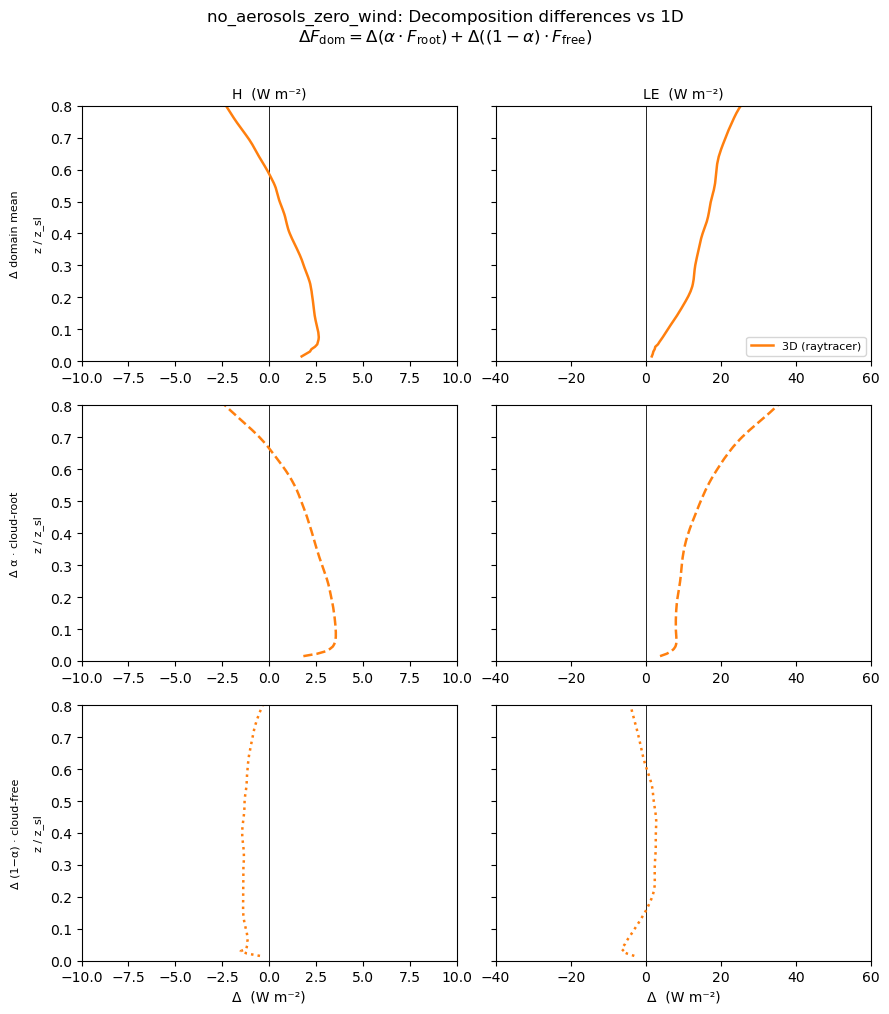

Saved flux_decomposition_diffs.pdf


In [8]:
# ── Figure B: differences vs 1D (3D free − 1D, 3D nudge − 1D) ───────────────
# Each component: Δ(domain mean), Δ(α·root contrib), Δ((1-α)·free contrib)
_baseline_key = '1D'
_diff_cases   = [c for c in CASES if c['key'] != _baseline_key]

ap_base   = abs_profiles[_baseline_key]
alpha_base = float(cloud_fracs[_baseline_key].mean()) if len(cloud_fracs[_baseline_key]) > 0 else np.nan

_comp_labels = ['domain mean', 'α · cloud-root', '(1−α) · cloud-free']
_comp_ls     = ['-', '--', ':']

fig, axes = plt.subplots(3, 2, figsize=(9, 10), sharey=True)

_xlims_diff = {'H': (-10, 10), 'LE': (-40, 60)}

for col, var in enumerate(['H', 'LE']):
    dom_key  = 'H_dom'  if var == 'H' else 'LE_dom'
    root_key = 'H_root' if var == 'H' else 'LE_root'
    free_key = 'H_free' if var == 'H' else 'LE_free'

    zeta = ap_base['zeta']
    base_dom  = np.nanmean(ap_base[dom_key],  axis=0)
    base_root = np.nanmean(ap_base[root_key], axis=0)
    base_free = np.nanmean(ap_base[free_key], axis=0)

    base_contrib_root = alpha_base * base_root
    base_contrib_free = (1 - alpha_base) * base_free

    for row, (comp_label, comp_ls) in enumerate(zip(_comp_labels, _comp_ls)):
        ax = axes[row, col]
        ax.axhline(1.0, color='gray', ls='--', lw=0.8)
        ax.axvline(0,   color='k',    ls='-',  lw=0.6)
        ax.set_ylim(0, 0.8)
        ax.set_xlim(*_xlims_diff[var])

        for case in _diff_cases:
            ap    = abs_profiles[case['key']]
            fracs = cloud_fracs[case['key']]
            if ap['n_reps'] == 0:
                continue

            alpha_mu = float(fracs.mean()) if len(fracs) > 0 else np.nan

            mu_dom  = np.nanmean(ap[dom_key],  axis=0)
            mu_root = np.nanmean(ap[root_key], axis=0)
            mu_free = np.nanmean(ap[free_key], axis=0)

            if row == 0:
                diff = mu_dom - base_dom
            elif row == 1:
                diff = alpha_mu * mu_root - base_contrib_root
            else:
                diff = (1 - alpha_mu) * mu_free - base_contrib_free

            mu_diff = diff
            # rep-level std: recompute per-rep contributions then take std
            if ap['n_reps'] > 1 and ap_base['n_reps'] > 1:
                if row == 0:
                    rep_diff = (np.nanmean(ap[dom_key], axis=0) - np.nanmean(ap_base[dom_key], axis=0))
                    sd = np.zeros_like(mu_diff)  # cross-case diff — no rep pairing; skip shading
                else:
                    sd = np.zeros_like(mu_diff)
            else:
                sd = np.zeros_like(mu_diff)

            ax.plot(mu_diff, zeta, color=case['color'], lw=1.8, ls=comp_ls, label=case['label'])

        if row == 0:
            ax.set_title('H  (W m⁻²)' if var == 'H' else 'LE  (W m⁻²)', fontsize=10)
        if row == 2:
            ax.set_xlabel('Δ  (W m⁻²)')
        if col == 0:
            ax.set_ylabel(f'Δ {comp_label}\n\nz / z_sl', fontsize=8)

# Legends
legend_cases = [Line2D([0],[0], color=c['color'], lw=1.8, label=c['label']) for c in _diff_cases]
axes[0, 1].legend(handles=legend_cases, fontsize=8, loc='lower right')

plt.suptitle(
    'no_aerosols_zero_wind: Decomposition differences vs 1D\n'
    r'$\Delta F_\mathrm{dom} = \Delta(\alpha \cdot F_\mathrm{root}) + \Delta((1-\alpha) \cdot F_\mathrm{free})$',
    y=1.01,
)
plt.tight_layout()
plt.savefig('flux_decomposition_diffs.pdf', bbox_inches='tight')
plt.show()
print('Saved flux_decomposition_diffs.pdf')


## Section B — L&P composite cross-sections

Cloud objects with chord ≥ 1 km, 11:30–15:30 LST (Lohou & Patton 2014).

**Methodology**: per-rep mean over events → mean-of-means across reps (each rep weighted equally).  
Cases with no event files yet print a warning and show a placeholder panel.  
Change `ORIENT` in the config cell to `'yz'` to see the perpendicular composite.

In [9]:
comp_data = {}
print(f'Loading composites  [orient={ORIENT}]')
for case in CASES:
    key = case['key']
    print(f'\n  {case["label"]}:')
    result = average_reps(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        n_reps=N_REPS, verbose=True,
    )
    comp_data[key] = result.get(ORIENT)
    if comp_data[key] is None:
        print(f'    -> no {ORIENT} events available yet (jobs still pending?)')

Loading composites  [orient=xz]

  1D (2stream):


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_01: 146 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_02: 118 events


...

/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  yz  rep_03: 148 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  yz  rep_04: 140 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:93: RuntimeWarning: Mean of empty slice
  out[f"{vn}_mean"]     = xr.DataArray(np.nanmean(stack, axis=0),
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


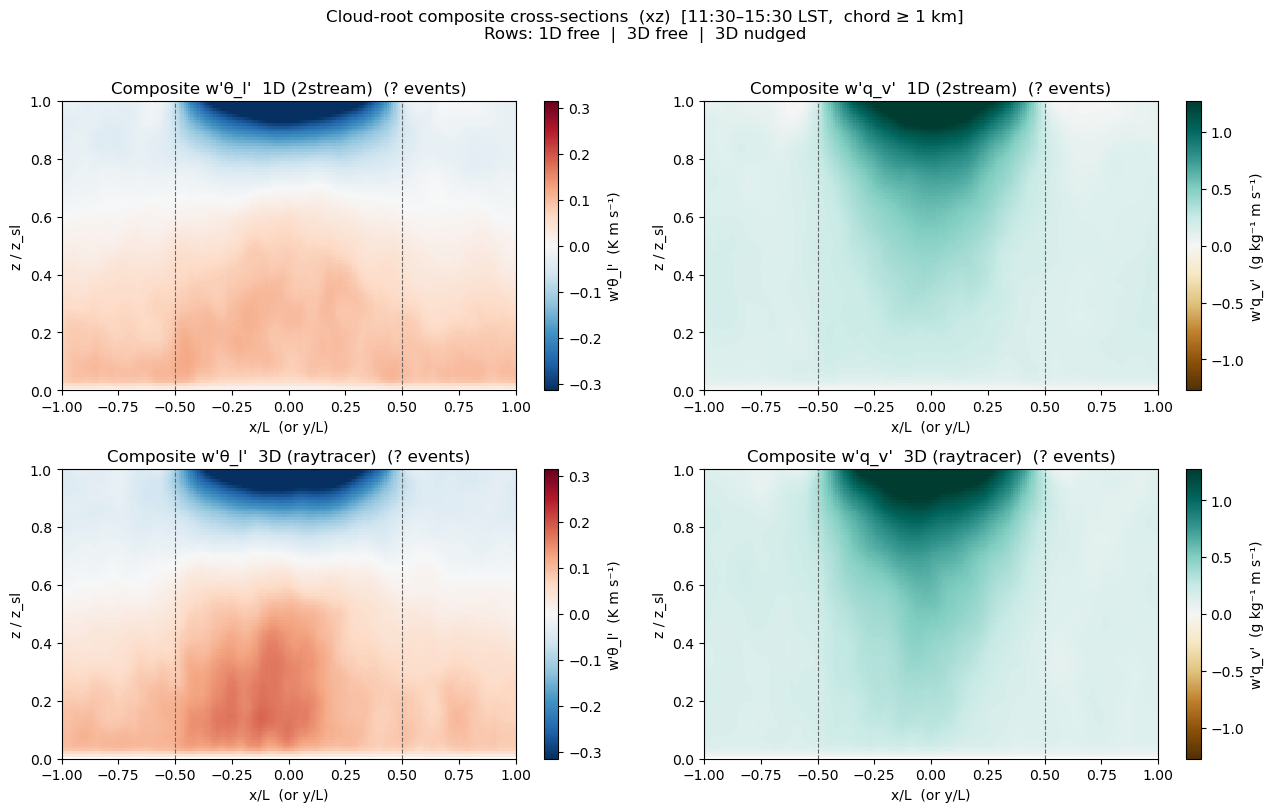

In [ ]:
_avail = {c['key']: comp_data[c['key']] for c in CASES if comp_data.get(c['key']) is not None}

if not _avail:
    print('No composite data available yet.')
else:
    # Shared colour limits across all available cases
    def _collect(vn):
        return np.concatenate([ds[vn].values.ravel() for ds in _avail.values()])

    vmax_thl = float(np.nanpercentile(np.abs(_collect('w_thl_mean')), 98))
    vmax_qv  = float(np.nanpercentile(np.abs(_collect('w_qv_mean')),  98))
    vlim_thl = (-vmax_thl, vmax_thl)
    vlim_qv  = (-vmax_qv,  vmax_qv)

    fig, axes = plt.subplots(len(CASES), 2, figsize=(13, 4 * len(CASES)))

    for row, case in enumerate(CASES):
        ax_l, ax_r = axes[row]
        if case['key'] not in _avail:
            for ax in (ax_l, ax_r):
                ax.text(0.5, 0.5,
                        f'Not yet available\n({case["label"]})',
                        ha='center', va='center', transform=ax.transAxes,
                        color='gray', fontsize=11)
                ax.set_xticks([]); ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_edgecolor('lightgray')
            continue
        plot_cloud_root_composite(
            ax_l, ax_r, _avail[case['key']],
            vlim_thl=vlim_thl, vlim_qv=vlim_qv,
            label=case['label'],
        )

    plt.suptitle(
        f'Cloud-root composite cross-sections  ({ORIENT})  '
        f'[11:30\u201315:30 LST,  chord \u2265 1 km]\n'
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

In [13]:
_avail[case['key']].n_reps

<xarray.DataArray 'n_reps' ()> Size: 4B
array(4, dtype=int32)

## Section C — Difference composites

Three pairwise differences (A − B, positive = A stronger):

| Row | Interpretation |
|-----|----------------|
| **3D − 1D** | Direct 3D RT effect on cloud-root turbulence in the free run |
| **3D nudge − 1D** | Same effect when the 3D BL is constrained to the 1D mean state |
| **3D nudge − 3D** | Effect of the nudging itself on cloud-root turbulent structure |

Skipping "3D nudged − 1D free": 3D_nudge has no composite data yet
Skipping "3D nudged − 3D free": 3D_nudge has no composite data yet


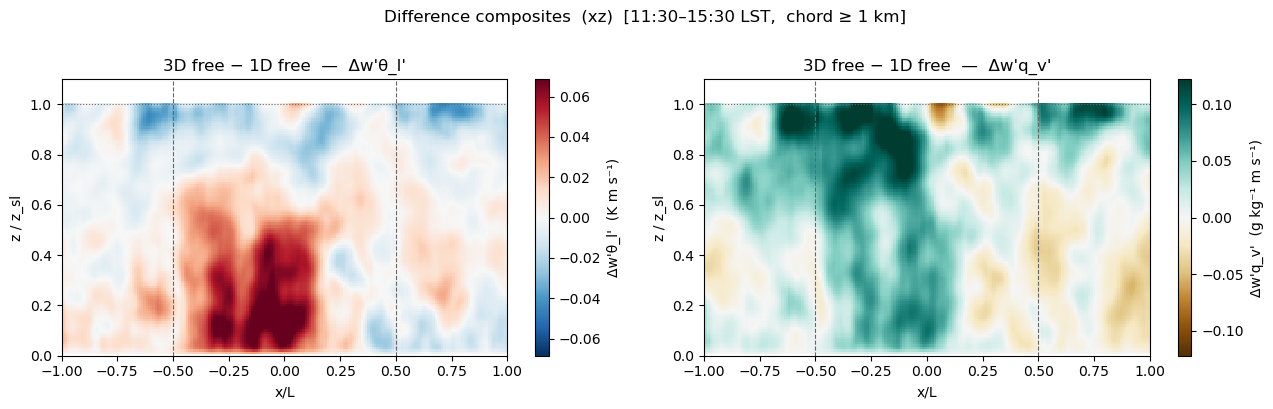

In [11]:
DIFFS = [
    ('3D',       '1D',  '3D free \u2212 1D free'),
    ('3D_nudge', '1D',  '3D nudged \u2212 1D free'),
    ('3D_nudge', '3D',  '3D nudged \u2212 3D free'),
]

diffs_ok      = [(a, b, lbl) for a, b, lbl in DIFFS if a in _avail and b in _avail]
diffs_missing = [(a, b, lbl) for a, b, lbl in DIFFS if a not in _avail or b not in _avail]

for a, b, lbl in diffs_missing:
    missing_key = a if a not in _avail else b
    print(f'Skipping "{lbl}": {missing_key} has no composite data yet')

if not diffs_ok:
    print('No differences can be computed yet.')
else:
    fig, axes = plt.subplots(len(diffs_ok), 2, figsize=(13, 4 * len(diffs_ok)))
    if len(diffs_ok) == 1:
        axes = axes[np.newaxis, :]

    for row, (key_a, key_b, lbl) in enumerate(diffs_ok):
        ds_a, ds_b = _avail[key_a], _avail[key_b]
        xL   = ds_a.xL.values
        z_nd = ds_a.z_nd.values

        for col, (var, cmap, clabel) in enumerate([
            ('w_thl_mean', 'RdBu_r', "\u0394w'\u03b8_l'  (K m s\u207b\xb9)"),
            ('w_qv_mean',  'BrBG',   "\u0394w'q_v'  (g kg\u207b\xb9 m s\u207b\xb9)"),
        ]):
            ax   = axes[row, col]
            diff = ds_a[var].values - ds_b[var].values
            vmax = float(np.nanpercentile(np.abs(diff), 98))
            pcm  = ax.pcolormesh(xL, z_nd, diff, cmap=cmap, shading='auto',
                                  vmin=-vmax, vmax=vmax)
            plt.colorbar(pcm, ax=ax, label=clabel)
            ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
            ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
            ax.set_xlabel('x/L')
            ax.set_ylabel('z / z_sl')
            ax.set_xlim(-1, 1)
            ax.set_ylim(0, 1.1)
            ax.set_title(f"{lbl}  \u2014  {clabel.split('(')[0].strip()}")

    plt.suptitle(
        f'Difference composites  ({ORIENT})  [11:30\u201315:30 LST,  chord \u2265 1 km]',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()